# Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
from collections import Counter

# Web Scraping

In [2]:
url = "https://www.gutenberg.org/cache/epub/84/pg84-images.html"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

raw_text = soup.get_text()
lines = raw_text.splitlines()
clean_lines = [line.strip() for line in lines if line.strip()]
full_text = " ".join(clean_lines)

full_text = full_text.lower()
for ch in ['"', '\u201c', '\u201d', '\u2018', '\u2019', '\n', '\r', '\t']:
    full_text = full_text.replace(ch, ' ')

tokens = full_text.split()
print(f"Tokens: {len(tokens)}")
print(' '.join(tokens[:20]))

Tokens: 78222
frankenstein | project gutenberg the project gutenberg ebook of frankenstein; or, the modern prometheus this ebook is for the use


# Preprocessing

In [3]:
word_counts = Counter(tokens)
print(f"Unique words: {len(word_counts)}")

vocab_words = [w for w, c in word_counts.items() if c >= 1]
vocab = {"<PAD>": 0, "<UNK>": 1}
for word in vocab_words:
    vocab[word] = len(vocab)

idx2word = {idx: word for word, idx in vocab.items()}
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

encoded = [vocab.get(word, 1) for word in tokens]
print(f"Encoded length: {len(encoded)}")

window_size = 100
data = []
targets = []

for i in range(len(encoded) - window_size):
    data.append(encoded[i : i + window_size - 1])
    targets.append(encoded[i + window_size - 1])

print(f"Sequences: {len(data)}")
print(f"Input length: {len(data[0])}")
print(f"Example target: '{idx2word[targets[0]]}'")

Unique words: 11296
Vocabulary size: 11298
Encoded length: 78222
Sequences: 78122
Input length: 99
Example target: 'the'


# Dataset & DataLoader

In [4]:
class TextDataset(Dataset):
    def __init__(self, data, targets):
        self.data    = torch.tensor(data,    dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.long)
    def __len__(self):
        return len(self.targets)
    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

dataset = TextDataset(data, targets)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"Train: {train_size} | Val: {val_size}")
x_batch, y_batch = next(iter(train_loader))
print(f"X shape: {x_batch.shape} | Y shape: {y_batch.shape}")

Train: 70309 | Val: 7813
X shape: torch.Size([64, 99]) | Y shape: torch.Size([64])


# Model

In [5]:
# Model

class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=1, dropout=0.3):
        super(TextLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        last_out = lstm_out[:, -1, :]
        out = self.fc(self.dropout(last_out))
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = TextLSTM(vocab_size=vocab_size).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print(model)

Device: cuda
Parameters: 2,279,842
TextLSTM(
  (embedding): Embedding(11298, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=11298, bias=True)
)


# Training (Early Stopping)

Epoch  1/15 | Train Loss: 6.9178 | Val Loss: 6.7157
Epoch  2/15 | Train Loss: 6.3399 | Val Loss: 6.5881
Epoch  3/15 | Train Loss: 6.0260 | Val Loss: 6.5404
Epoch  4/15 | Train Loss: 5.7408 | Val Loss: 6.5482
Epoch  5/15 | Train Loss: 5.4708 | Val Loss: 6.6139
Epoch  6/15 | Train Loss: 5.1959 | Val Loss: 6.6987

Early stopping at epoch 6

Best Val Loss: 6.5404


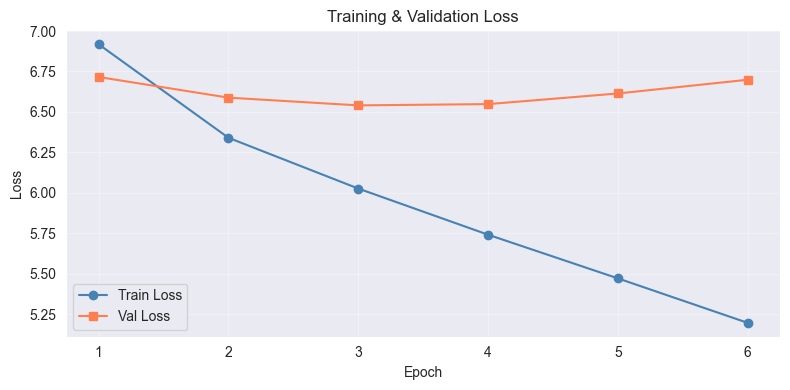

In [6]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

num_epochs = 15
patience = 3
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        predictions = model(x_batch)
        loss = criterion(predictions, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()
        epoch_train_loss += loss.item()

    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)
            epoch_val_loss += loss.item()

    avg_train = epoch_train_loss / len(train_loader)
    avg_val = epoch_val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)
print(f"\nBest Val Loss: {best_val_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Train Loss', color='steelblue')
plt.plot(range(1, len(val_losses)+1), val_losses, marker='s', label='Val Loss', color='coral')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Text Generation

In [7]:
def generate_text(model, seed_text, vocab, idx2word, num_words=100, temperature=1.0):
    model.eval()
    seed_tokens = seed_text.lower().split()
    seed_encoded = [vocab.get(word, 1) for word in seed_tokens]
    window = [0] * (99 - len(seed_encoded)) + seed_encoded
    window = window[-99:]
    generated_words = seed_tokens.copy()

    with torch.no_grad():
        for _ in range(num_words):
            x = torch.tensor([window], dtype=torch.long).to(device)
            output = model(x) / temperature
            probs = torch.softmax(output, dim=1)
            next_idx = torch.multinomial(probs, num_samples=1).item()
            generated_words.append(idx2word.get(next_idx, '<UNK>'))
            window = window[1:] + [next_idx]

    return " ".join(generated_words)


seed = "the monster looked at me with"
print("=" * 60)
print(f"Seed: '{seed}'")
print("=" * 60)

for temp in [0.5, 1.0, 1.5]:
    print(f"\nTemperature {temp}:")
    print(generate_text(model, seed, vocab, idx2word, num_words=100, temperature=temp))

Seed: 'the monster looked at me with'

Temperature 0.5:
the monster looked at me with a small and its clear which i had been no longer and this was a few of the sea, of the most delightful i was at first about to make the same spot i had been the same gigantic useless the trial was now i had been a great of my own heart but i was overcome to fly and that from the monster i was on the same grief i was not with the words of my education my father s house. and i saw the monster of the same country and a thousand minute summer, articulate the wind

Temperature 1.0:
the monster looked at me with black, with earlier which he not mistaken; i enjoying as them to achieved, and other and solitude. my heart-moving leisure across the rhine. and on the cottages, which again distance and his base at foes too the utmost events years with affection. when he you must one of other excellent (or heaven, from every cottages, their things. long solitary days, night i could not glowing and one by the evenin

# Analysis

ANALYSIS

Best Train Loss: 5.1959
Best Val Loss:   6.5404
Train Perplexity: 180.5
Val Perplexity:   692.5

<UNK> statistics:
  Temperature 0.5: 0 <UNK> (0.0%)
  Temperature 1.0: 0 <UNK> (0.0%)
  Temperature 1.5: 0 <UNK> (0.0%)


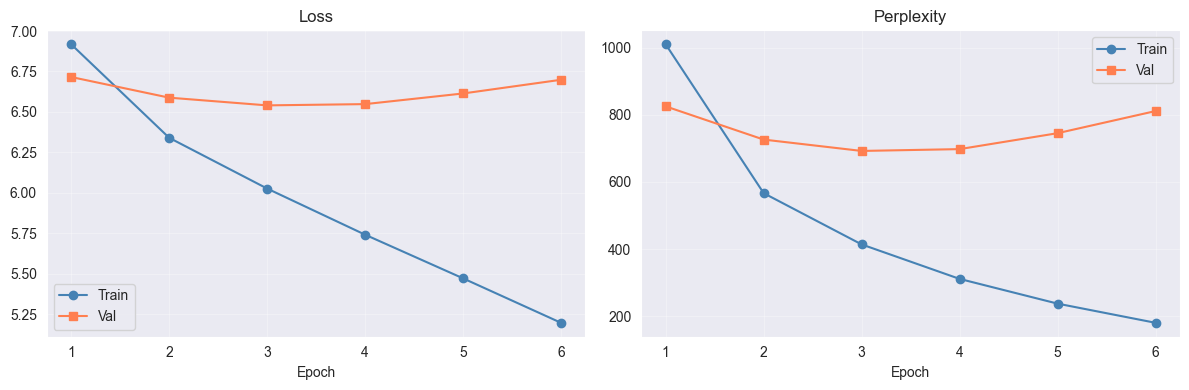

In [8]:
print("=" * 60)
print("ANALYSIS")
print("=" * 60)

print(f"\nBest Train Loss: {min(train_losses):.4f}")
print(f"Best Val Loss:   {best_val_loss:.4f}")
print(f"Train Perplexity: {np.exp(min(train_losses)):.1f}")
print(f"Val Perplexity:   {np.exp(best_val_loss):.1f}")

print("\n<UNK> statistics:")
for temp in [0.5, 1.0, 1.5]:
    text  = generate_text(model, seed, vocab, idx2word, num_words=100, temperature=temp)
    words = text.split()
    unk   = words.count('<UNK>')
    print(f"  Temperature {temp}: {unk} <UNK> ({unk/len(words)*100:.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Train', color='steelblue')
ax1.plot(range(1, len(val_losses)+1),   val_losses,   marker='s', label='Val',   color='coral')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

train_perp = [np.exp(l) for l in train_losses]
val_perp = [np.exp(l) for l in val_losses]
ax2.plot(range(1, len(train_perp)+1), train_perp, marker='o', label='Train', color='steelblue')
ax2.plot(range(1, len(val_perp)+1),   val_perp,   marker='s', label='Val',   color='coral')
ax2.set_title('Perplexity')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
